In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import arviz as az
import json

In [2]:
def phi_var(time, r):
    t0 = 11
    ts = 90
    lamda = 0.009
    M0 = 12058
    M_stable = 2581645
   
    # Numerator
    numerator = (M_stable *  np.exp(ts * lamda)) - M0
    
    # Denominator components
    term1 = (np.exp(ts * lamda) - np.exp(t0 * lamda)) / lamda
    
    # Second term in denominator
    exp_t0_r_diff = np.exp(t0 * lamda) * np.exp((ts -t0) * (lamda - r))
    coefficient = ((ts-t0)**2 * (lamda - r)**2 - 2*(ts-t0) * (lamda - r) + 2)
    term2 = (exp_t0_r_diff * coefficient) / (lamda - r)**3
    
    term3 = 2 * np.exp(lamda * t0)
    
    denominator = term1 + term2 - term3
    
    phi0 = numerator / denominator
    
    # Calculate phi_var
    phi_var_func = phi0 * (1 + (time - 11)**2 * np.exp(-r * (time - 11)))
    
    return phi0

print(phi_var(11, 2.2))
print(phi_var(11, 0.5))
print(phi_var(11, 0.25))



46372.45796419831
46372.45796419839
46372.52149622774


/tmp/ipykernel_2592513/2347964659.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


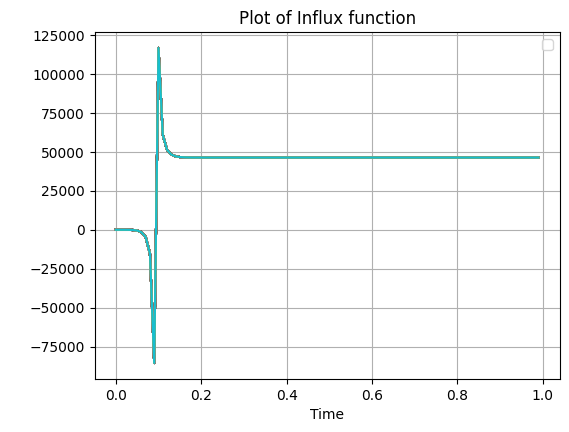

In [3]:
# Function to plot the phi_var function for different values of r
def plot_phi_var():
    time_values = 11
    r_values = np.arange(0, 1.0, 0.01)
    
    plt.figure(figsize=(6, 4.5))
    
    for r in r_values:
        phi_values = [phi_var(time_values, r) for r in r_values]
        plt.plot(r_values, phi_values)
    
    plt.title('Plot of Influx function')
    plt.xlabel('Time')
    plt.ylabel(' ')
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
    plt.legend()
    plt.grid()
    plt.show()

# Test the plotting function
plot_phi_var()

In [4]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')

# #Open csv files 
# dir_path = '/home/apoorva/Desktop/work/MZ_analysis/data/output_anchor'
# csv_files = [dir_path + '/' + file for file in os.listdir(dir_path) if file.endswith('.csv')]
# print(csv_files)

# from cmdstanpy import from_csv
# data_neutral = from_csv(csv_files)

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny/Vary Source/output_influxbiphasic.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")
# print(df_new.head(10))
# print(df_ont.head(10))

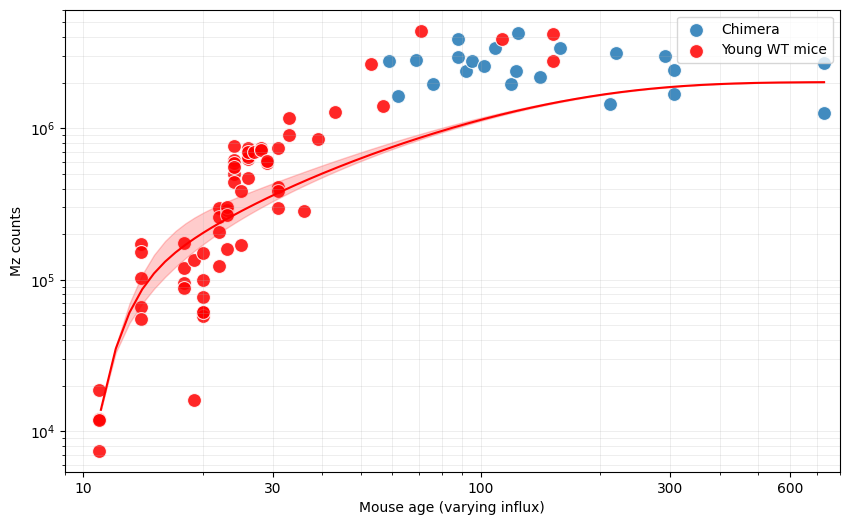

In [5]:
# ts1= np.arange(11, 750, 1)
# ts1= np.arange(11, 152, 1)

ts2 = np.arange(11.1, 732.1, 1)

# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(ts2, np.mean(data_neutral.MZ_counts_pred, axis=0), color = 'red')
plt.fill_between(ts2, np.percentile(data_neutral.MZ_counts_pred, 2.5, axis=0), np.percentile(data_neutral.MZ_counts_pred, 97.5, axis=0), alpha=0.2, color='red')
plt.xscale('log')
plt.yscale('log')
# plt.ylim(5*1e3, 1e7)
plt.xlim(9, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (varying influx)')
plt.ylabel('Mz counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



<Axes: title={'center': 'r'}>

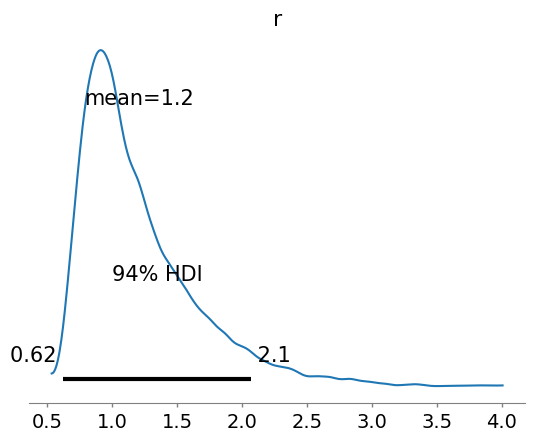

In [6]:
az.plot_posterior(data_neutral, var_names=['r'], kind='kde')

In [7]:
# Posterior distribution of parameters

# az.plot_posterior(data_neutral, var_names=['r_phi', 'phi','lambda'], kind='kde')
# az.plot_posterior(data_neutral, var_names=['r_phi', 'P0'], kind='kde')


/tmp/ipykernel_2592513/2287612422.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes.set_xlim(0, 750)


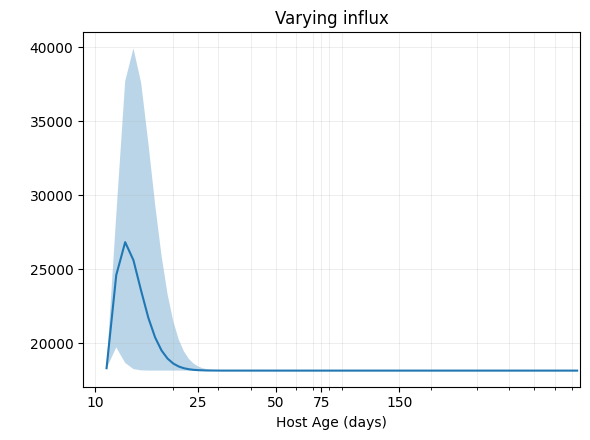

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4.5))
axes.plot(ts2, np.mean(data_neutral.influx_rate, axis=0))
axes.fill_between(ts2, np.quantile(data_neutral.influx_rate, 0.025, axis=0), np.quantile(data_neutral.influx_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.05)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xscale('log')
# axes.set_yscale('log')
axes.set_xlim(0, 750)
axes.set_xticks([10, 25, 50, 75, 150])
axes.set_xticklabels([10, 25, 50, 75, 150])
axes.set_ylabel(' ')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying influx')
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'r'}>, <Axes: title={'center': 'r'}>]],
      dtype=object)

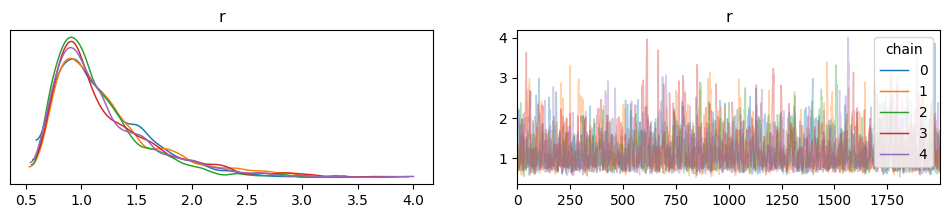

In [9]:
az.plot_trace(data_neutral, var_names=['r'], compact=False, legend=True)

In [10]:
# Rate of influx of T1 into MZ

# def phi(t, r_phi):
    # phi = 0.014
    # phi_var = phi / (1 + np.exp(-r_phi * (t-20)))
    # return phi_var
# def phi(t, r_phi):
#     if(t < 40):
#      r_phi = 0.017
#      phi = 0.014
#      phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.8))
#     else:
#       phi_var = 0.014
#     return(phi_var)

def phi(t, r_phi, alpha, t0):
    phi_value = 0.014  # Assuming phi is a constant value
    phi_var =  ((phi_value - alpha) / (1 + np.exp(-(r_phi) * (t- t0)))) + alpha
    return phi_var

def P(t):

    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

t = np.arange(11, 152, 1)

# influx_p = np.zeros((8000, 739))
# for i in range(0, 739):  # Ensure the loop does not exceed the bounds
#     # influx_p[:, i] = (phi(i + 11, data_neutral.r_phi, data_neutral.alpha) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
#     influx_p[:, i] = (phi(i + 11, data_neutral.r_phi) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
    

influx_rate = np.zeros((8000, 739))
for i in range(0, 739):  # Ensure the loop does not exceed the bounds
    influx_rate[:, i] = phi(i + 11, data_neutral.r_phi, data_neutral.alpha, data_neutral.t0) 
 


# # influx = np.array(influx)
# print(len(influx_p))
# print(influx_p.shape)
# # print(np.quantile(influx_p, 0.025, axis=0))
# # print(np.quantile(influx_p, 0.975, axis=0))

# # Plot precursor influx with 95% CI

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(influx_p, axis=0))
# axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.15)
# # axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# # axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xlim(10, 750)
# axes.set_xticks([50, 200, 350, 500])
# axes.set_xticklabels([50, 200, 350, 500])
# axes.set_ylabel('Fraction of influx')
# axes.set_xlabel('Host Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# axes.set_title('Proportion of influx of TA44.1 precursor cells into the MZ pool')
# plt.tight_layout()
# plt.show()


AttributeError: Unknown variable name: r_phi
Available variables are sigma, r, y1, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, influx_rate, log_lik_Mz, residuals_Mz

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ts1= np.arange(11, 152, 1)
axes.plot(ts1, np.mean(influx_rate, axis=0))
axes.fill_between(ts1, np.quantile(influx_rate, 0.025, axis=0), np.quantile(influx_rate, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_xscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 800)
axes.set_xticks([ 11, 40, 200, 400, 600])
axes.set_xticklabels([ 11, 40, 200, 400, 600])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying influx rate')
plt.tight_layout()
plt.show()